## This project is a placement prediction project.

**For a student, `placement` generally means getting a temporary job or hands-on work experience tied to their studies, or securing a permanent job through their school before graduating**

In [120]:
from sklearn.linear_model import LogisticRegression # This is a classification problem so we'll be using logistic regression for it
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [176]:
df

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,1
1,4,69,5,3,8,56,100.00,1
2,11,60,7,6,10,45,100.00,1
3,8,99,9,8,4,55,90.17,1
4,5,52,8,6,8,40,78.82,1
...,...,...,...,...,...,...,...,...
9995,2,58,9,7,8,88,69.31,0
9996,7,98,6,9,4,87,100.00,1
9997,10,44,8,5,10,37,95.94,1
9998,10,75,7,5,8,52,88.61,1


### Data Cleaning/Preprocessing

In [121]:
# Loading the dataset

df = pd.read_csv('student_dataset_10000_rows.csv')

In [122]:
# Checking for duplicates

df.duplicated().sum()

np.int64(0)

In [123]:
# Checking for null values

df.isnull().sum()

study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
exam_score               0
placement_status         0
dtype: int64

In [124]:
# Checking the total number of columns

df.columns

Index(['study_hours', 'attendance', 'sleep_hours', 'internet_usage',
       'assignments_completed', 'previous_score', 'exam_score',
       'placement_status'],
      dtype='str')

In [183]:
vals = 2+3+5+7+8+6
vals/6

5.166666666666667

In [178]:
values = [2,3,5,6,7,8]
values = np.array(values)

np.mean(values)

np.float64(5.166666666666667)

In [125]:
# Checking the info of the dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  str    
dtypes: float64(1), int64(6), str(1)
memory usage: 625.1 KB


In [126]:
# How correlated the data is tells us which feature affects the other the most.
# 1 = Perfectly move together
# 0 = Not related
# -1 = Move in opposite directions

df.corr(numeric_only=True)

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
study_hours,1.000000,0.003801,-0.005255,0.006684,-0.000425,0.009451,0.562528
attendance,0.003801,1.000000,-0.003981,-0.014539,-0.012892,0.001588,0.223367
sleep_hours,-0.005255,-0.003981,1.000000,-0.000038,-0.008234,0.023916,0.144675
internet_usage,0.006684,-0.014539,-0.000038,1.000000,0.020536,0.005371,-0.151896
assignments_completed,-0.000425,-0.012892,-0.008234,0.020536,1.000000,0.004178,0.387609
previous_score,0.009451,0.001588,0.023916,0.005371,0.004178,1.000000,0.318805
exam_score,0.562528,0.223367,0.144675,-0.151896,0.387609,0.318805,1.000000


In [127]:
df.head(2)

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.0,Placed
1,4,69,5,3,8,56,100.0,Placed


In [128]:
# Checking the number of values present in the target column
df['placement_status'].value_counts()

placement_status
Placed        8356
Not Placed    1644
Name: count, dtype: int64

In [129]:
# Mapping the target class

df['placement_status'] = df['placement_status'].map({'Placed': 1, 'Not Placed': 0})

In [130]:
df['placement_status'].value_counts()

placement_status
1    8356
0    1644
Name: count, dtype: int64

In [131]:
comparison = df[['study_hours', 'sleep_hours']]

# Exploratory Data Analysis
---

### Univariate Analysis

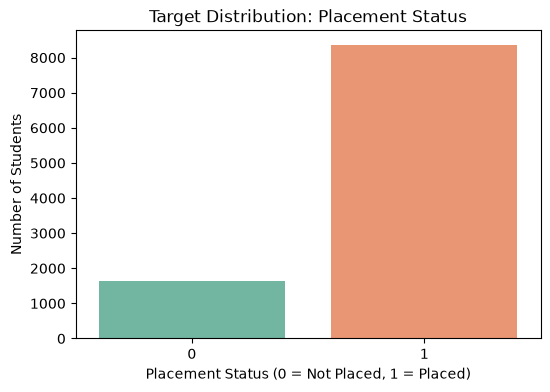

In [132]:
# 1. Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='placement_status', data=df, palette='Set2', hue='placement_status', legend=False)
plt.title('Target Distribution: Placement Status')
plt.xlabel('Placement Status (0 = Not Placed, 1 = Placed)')
plt.ylabel('Number of Students')
plt.show()


In [184]:
df

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,1
1,4,69,5,3,8,56,100.00,1
2,11,60,7,6,10,45,100.00,1
3,8,99,9,8,4,55,90.17,1
4,5,52,8,6,8,40,78.82,1
...,...,...,...,...,...,...,...,...
9995,2,58,9,7,8,88,69.31,0
9996,7,98,6,9,4,87,100.00,1
9997,10,44,8,5,10,37,95.94,1
9998,10,75,7,5,8,52,88.61,1


**Shows the number of students that were placed and those that were nopt placed.**

> *Note: This dataset is heavily imbalanced*

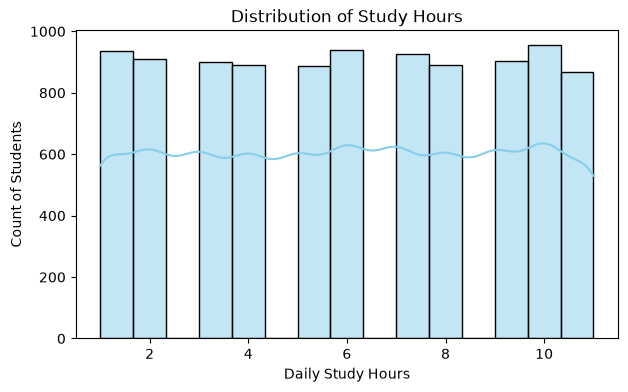

In [133]:
plt.figure(figsize=(7, 4))
sns.histplot(df['study_hours'], bins=15, kde=True, color='skyblue')
plt.title('Distribution of Study Hours')
plt.xlabel('Daily Study Hours')
plt.ylabel('Count of Students')
plt.show()


> - **The horizontal axis (X) represents the number of study hours from ~1 hour up to ~ 12+ hours.**

> - **The vertical axis (Y) represents the count (how many students fall into that study-hour bracket).**

<Axes: xlabel='exam_score', ylabel='Count'>

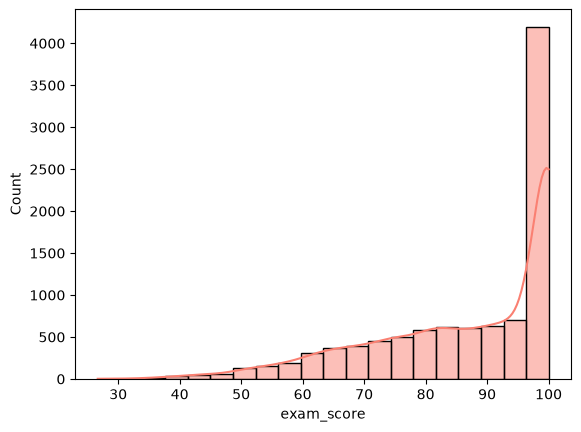

In [134]:
sns.histplot(x = 'exam_score', data = df, bins=20, kde=True, color='salmon')

# This is heavily skewed on the left.

### Bivariate Analysis

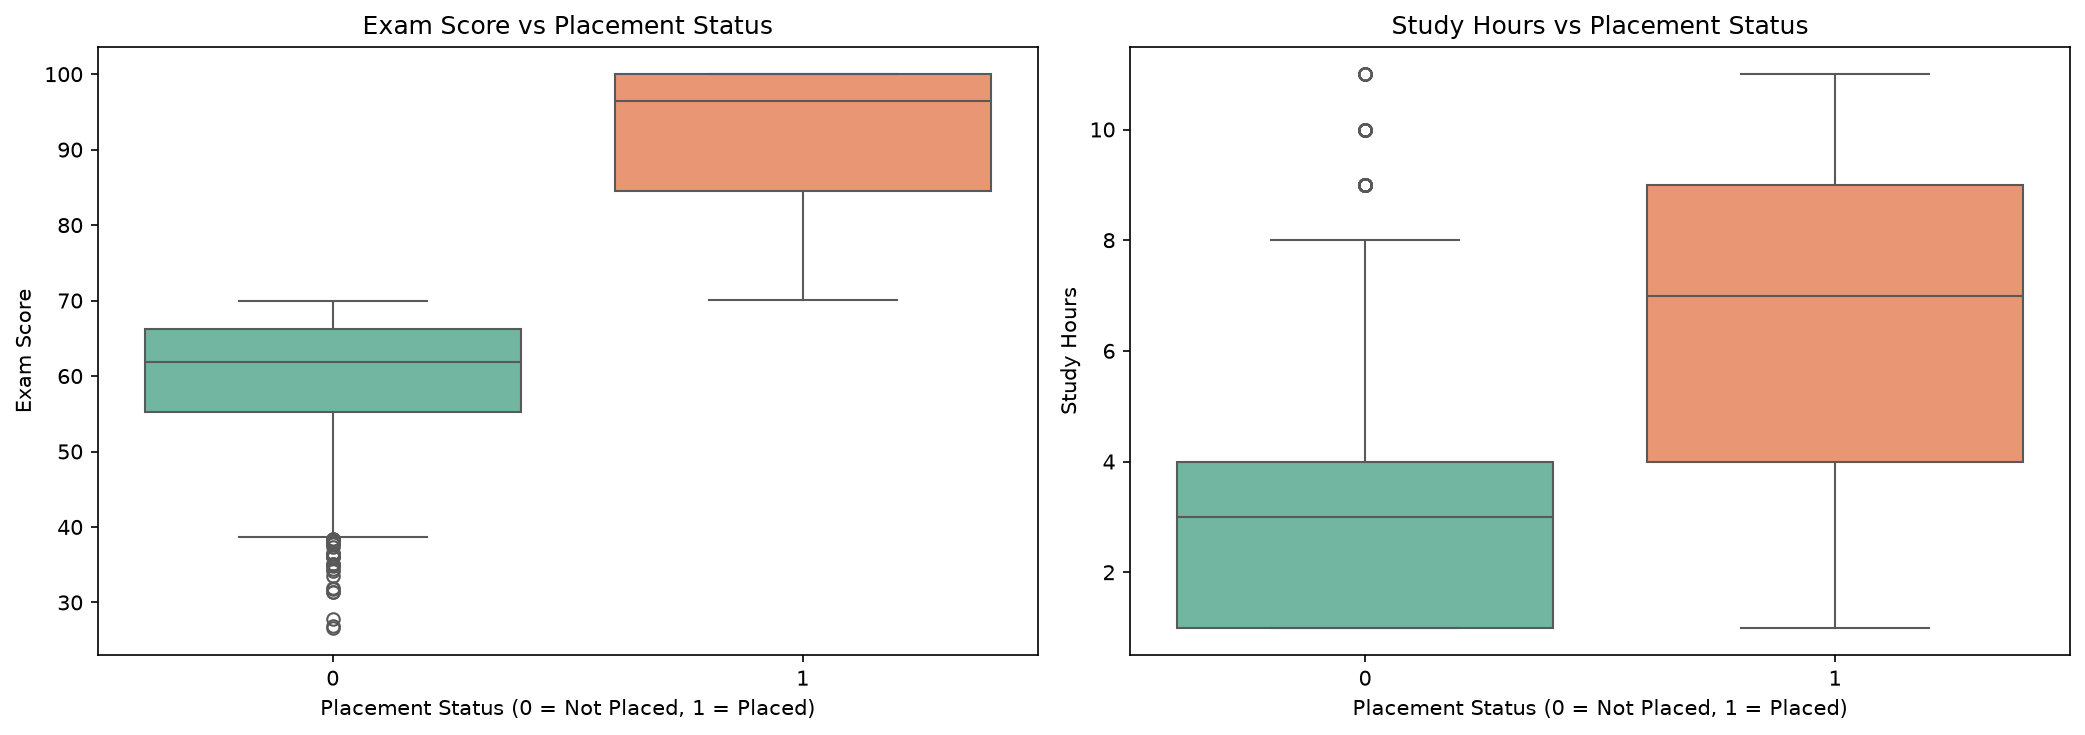

In [135]:
# Comparing Exam Score and Study Hours against Placement Status
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5), dpi=150)

# 1. Exam Score vs Placement
sns.boxplot(x='placement_status', y='exam_score', data=df, hue='placement_status', palette='Set2', ax=axes[0], legend=False)
axes[0].set_title('Exam Score vs Placement Status')
axes[0].set_xlabel('Placement Status (0 = Not Placed, 1 = Placed)')
axes[0].set_ylabel('Exam Score')

# 2. Study Hours vs Placement
sns.boxplot(x='placement_status', y='study_hours', data=df, hue='placement_status', palette='Set2', ax=axes[1], legend=False)
axes[1].set_title('Study Hours vs Placement Status')
axes[1].set_xlabel('Placement Status (0 = Not Placed, 1 = Placed)')
axes[1].set_ylabel('Study Hours')

plt.tight_layout()
plt.show()


**How to read the Boxplot:**

- **The line inside the box:** The **median** (the middle student's score).
- **The box itself:** Represents the middle 50% of students (25th to 75th percentile).
- **The whiskers (top and bottom lines):** The lowest and highest scores (excluding extreme outliers).

The Key Insight:

- Look at the **Exam Score** boxplot: Notice how the box for `1 (Placed)` sits way higher than `0 (Not Placed)` with almost zero overlap!
- This tells you immediately: Exam Score is a powerhouse predictor. If a student's score drops below a certain number, their chance of placement plummets.
- The same happens with Study Hours: Placed students consistently put in more study hours.

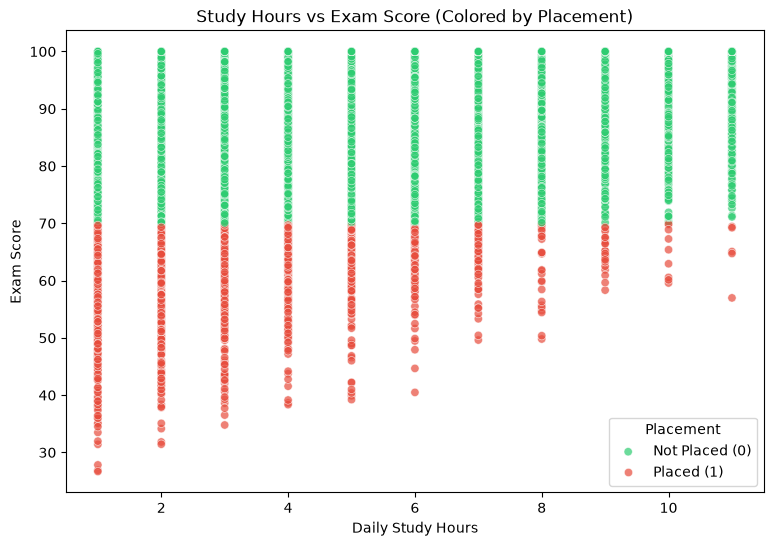

In [136]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x='study_hours', 
    y='exam_score', 
    hue='placement_status', 
    data=df, 
    palette=['#e74c3c', '#2ecc71'], # Red for 0 (Not Placed), Green for 1 (Placed)
    alpha=0.7
)
plt.title('Study Hours vs Exam Score (Colored by Placement)')
plt.xlabel('Daily Study Hours')
plt.ylabel('Exam Score')
plt.legend(title='Placement', labels=['Not Placed (0)', 'Placed (1)'])
plt.show()


- **X-axis = study_hours, Y-axis = exam_score.**

- **Each dot represents a student.**

- **hue='placement_status' colors the dots by whether the student was Placed (1) or Not Placed (0).**

- **Look at where the two colors fall. Notice that students with high exam scores and high study hours are almost all `Placed (1)`, while students with low exam scores are clustered at the bottom as `Not Placed (0)`.**

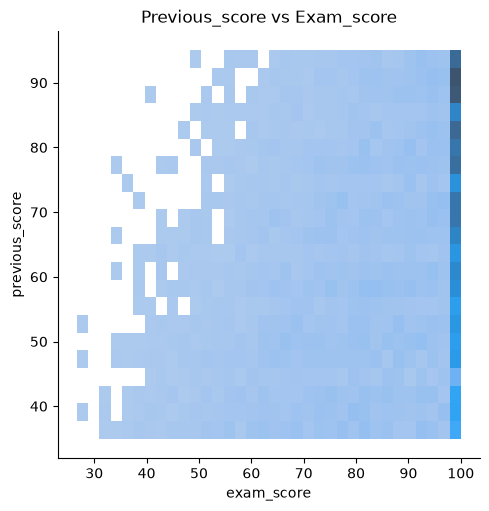

In [137]:
sns.displot(x='exam_score', y='previous_score', data=df)
plt.title('Previous_score vs Exam_score')
plt.show()

**The Insight: Points are clustered along a diagonal band, meaning students who did well previously generally score well on the exam too.**

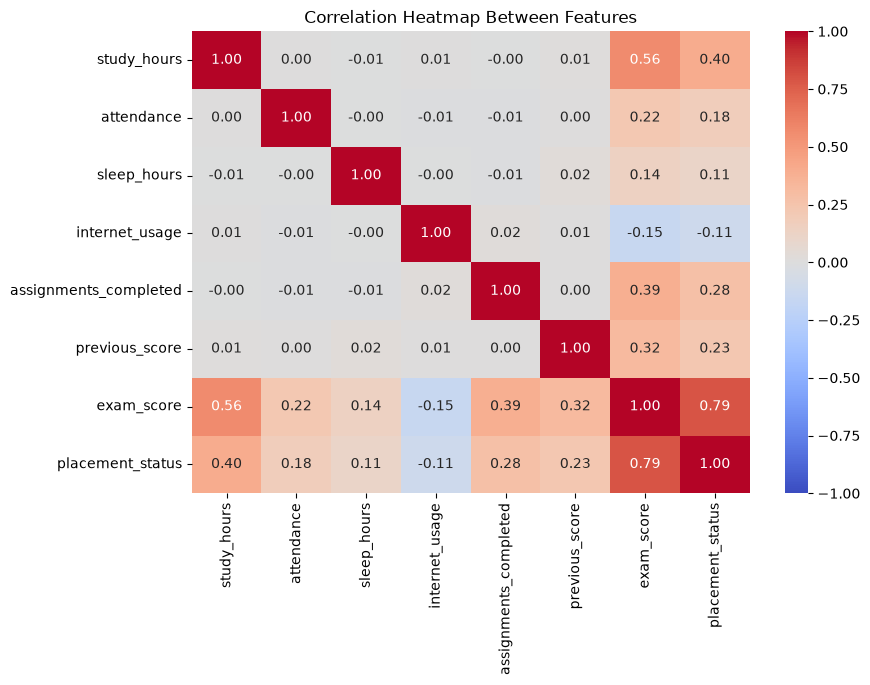

In [138]:
plt.figure(figsize=(9, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap Between Features')
plt.show()

How to read this:

- `+1.0` **(Dark Red):** Strong positive relationship (as one goes up, the other goes up, like `study_hours` and `exam_score` at `+0.56`).

- `0.0` **(White/Neutral):** No linear relationship (like `sleep_hours` with attendance).

- `-1.0` **(Dark Blue):** Negative relationship (as one goes up, the other goes down, like `internet_usage` with `exam_score` at `-0.15`).

In [139]:
df.columns

Index(['study_hours', 'attendance', 'sleep_hours', 'internet_usage',
       'assignments_completed', 'previous_score', 'exam_score',
       'placement_status'],
      dtype='str')

## Spliting the dataset test and train

In [140]:
from sklearn.model_selection import train_test_split

In [141]:
X = df.drop('placement_status', axis=1)
X = X.values
X = np.array(X)
X

array([[  7.  ,  56.  ,   8.  , ...,  10.  ,  62.  , 100.  ],
       [  4.  ,  69.  ,   5.  , ...,   8.  ,  56.  , 100.  ],
       [ 11.  ,  60.  ,   7.  , ...,  10.  ,  45.  , 100.  ],
       ...,
       [ 10.  ,  44.  ,   8.  , ...,  10.  ,  37.  ,  95.94],
       [ 10.  ,  75.  ,   7.  , ...,   8.  ,  52.  ,  88.61],
       [  2.  ,  70.  ,   6.  , ...,  16.  ,  52.  ,  78.96]],
      shape=(10000, 7))

In [142]:
y = df['placement_status']
y = y.values
y = np.array(y)
y

array([1, 1, 1, ..., 1, 1, 1], shape=(10000,))

In [143]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.3,
    stratify = y,
    random_state = 42,
    shuffle = True
)

In [144]:
print(X_train.shape, X_test.shape)

(7000, 7) (3000, 7)


In [145]:
print(y_train.shape, y_test.shape)

(7000,) (3000,)


In [146]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [147]:
# Scaling the training dataset for better prediction

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Training with Logistic Regression

> - **The goal is to predict the right class from the two classes, `Placed` or `Not-Placed`**

In [148]:
log_reg = LogisticRegression()

model = log_reg.fit(X_train_scaled, y_train)

In [149]:
# Check feature importance (Coefficients)
feature_names = df.drop('placement_status', axis=1).columns
coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Weight (Coefficient)': model.coef_[0]
}).sort_values(by='Weight (Coefficient)', ascending=False)

print("Model Intercept (Bias):", model.intercept_[0])
print("\nFeature Weights:")
print(coefficients)


Model Intercept (Bias): 14.200429570227131

Feature Weights:
                 Feature  Weight (Coefficient)
6             exam_score             12.284765
0            study_hours              0.365497
4  assignments_completed              0.240064
1             attendance              0.214877
5         previous_score              0.154031
2            sleep_hours              0.129154
3         internet_usage             -0.122928


In [150]:
model.intercept_

array([14.20042957])

In [151]:
probabilities[:5, 0].round(4)

array([0., 0., 1., 0., 0.])

In [152]:
# Get predicted probabilities
# Column 0 = Probability of Not Placed (0)
# Column 1 = Probability of Placed (1)
probabilities = model.predict_proba(X_test_scaled)

# Let's inspect the first 5 test students
prob_df = pd.DataFrame({
    'Prob_Not_Placed (Class 0)': probabilities[:5, 0].round(4),
    'Prob_Placed (Class 1)': probabilities[:5, 1].round(4),
    'Model_Decision': prediction[:5],
    'Actual_Status': y_test[:5]
})

print(prob_df)


   Prob_Not_Placed (Class 0)  Prob_Placed (Class 1)  Model_Decision  \
0                        0.0                    1.0               1   
1                        0.0                    1.0               1   
2                        1.0                    0.0               0   
3                        0.0                    1.0               1   
4                        0.0                    1.0               1   

   Actual_Status  
0              1  
1              1  
2              0  
3              1  
4              1  


In [153]:
prediction = model.predict(X_test_scaled)

In [154]:
print(f'Model Prediction   --->   {prediction[:10]}\n')
print(f'Actual Prediction  --->   {y_test[:10]}')

Model Prediction   --->   [1 1 0 1 1 1 0 1 1 0]

Actual Prediction  --->   [1 1 0 1 1 1 0 1 1 0]


##### Checking the performance of our model using an evaluation metric.

In [155]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report

In [156]:
def evaluation_metric(y_true, y_pred):
    precision = precision_score(y_true, y_pred, average='binary')
    recall = recall_score(y_true, y_pred, average='binary')
    f1 = f1_score(y_true, y_pred, average='binary')
    accuracy = accuracy_score(y_true, y_pred)

    print(f'Precision Score: {precision:.4f}')
    print(f'Recall Score: {recall:.4f}')
    print(f'F1 Score: {f1:.4f}')
    print(f'Accuracy Score: {accuracy:.4f}')

In [157]:
# Evaluation Metric

evaluation_metric(y_test, prediction)

Precision Score: 0.9984
Recall Score: 0.9992
F1 Score: 0.9988
Accuracy Score: 0.9980


In [158]:
probabilities = model.predict_proba(X_test_scaled)
# probabilities[:, 1] gives the probability of being Placed (Class 1)
probabilities[:, 1]


array([1.00000000e+00, 9.99999971e-01, 4.10345652e-07, ...,
       1.00000000e+00, 9.99999990e-01, 9.00634249e-02], shape=(3000,))

In [159]:
y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       493
           1       1.00      1.00      1.00      2507

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



<Figure size 600x500 with 0 Axes>

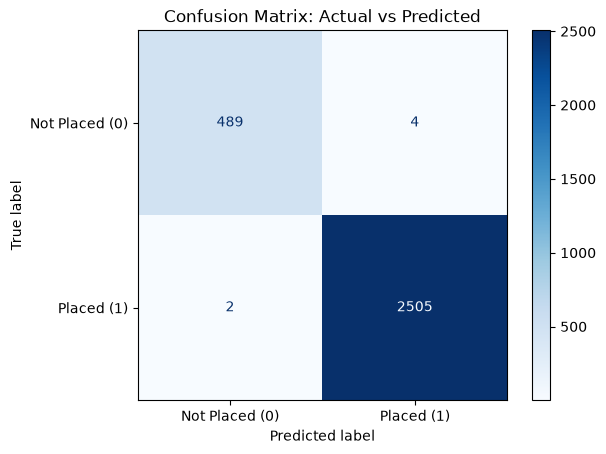

In [160]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, prediction)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Placed (0)', 'Placed (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: Actual vs Predicted')
plt.grid(False)
plt.show()


The confusion matrix above simply means:
- True Negatives: for all the predictions that were truly negative the model was able to predict all 489 of them correctly.

- False Negatives: The amount of times the model predicted a positive when it was actually a negative was 2 times.

- True Positives: For all the actual positives values the model was able to predict 2505 of them correctly.

- False Positives: The amount of times the model predicted a negative when it was actually a positive was 4 times.

In [161]:
probabilities[:, 1].shape

(3000,)

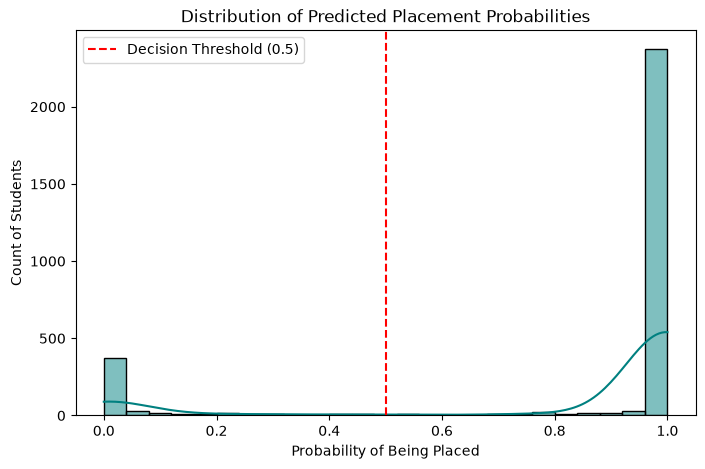

In [162]:
# Predicted Probability Distribution
plt.figure(figsize=(8, 5))
sns.histplot(probabilities[:, 1], bins=25, kde=True, color='teal')
plt.axvline(x=0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
plt.title('Distribution of Predicted Placement Probabilities')
plt.xlabel('Probability of Being Placed')
plt.ylabel('Count of Students')
plt.legend()
plt.show()


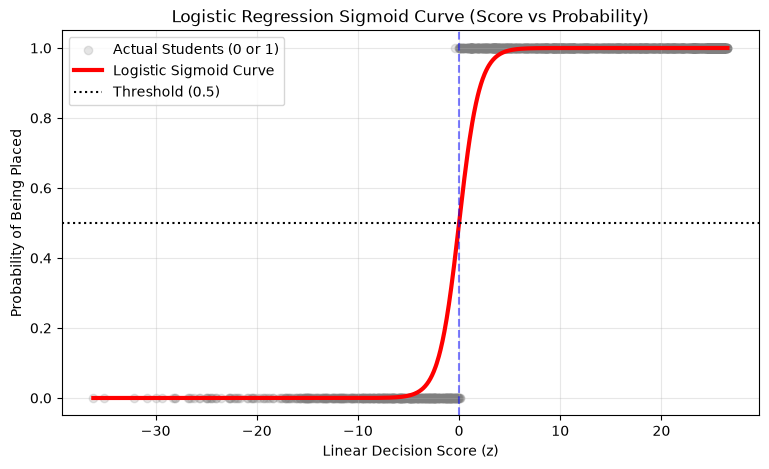

In [163]:
# 1. Calculate the linear score z = w*X + b
z_scores = model.decision_function(X_test_scaled)

# 2. Get the probability of placement
prob_placed = probabilities[:, 1]

# 3. Sort values so the line plots smoothly
sorted_indices = np.argsort(z_scores)
z_sorted = z_scores[sorted_indices]
prob_sorted = prob_placed[sorted_indices]

# 4. Plot the Sigmoid S-Curve
plt.figure(figsize=(9, 5))
plt.scatter(z_scores, y_test, alpha=0.2, color='gray', label='Actual Students (0 or 1)')
plt.plot(z_sorted, prob_sorted, color='red', linewidth=3, label='Logistic Sigmoid Curve')
plt.axhline(0.5, color='black', linestyle=':', label='Threshold (0.5)')
plt.axvline(0, color='blue', linestyle='--', alpha=0.5)

plt.title('Logistic Regression Sigmoid Curve (Score vs Probability)')
plt.xlabel('Linear Decision Score (z)')
plt.ylabel('Probability of Being Placed')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# Function to predict placement for any student
def predict_new_student(study_hours, attendance, sleep_hours, internet_usage, 
                        assignments_completed, previous_score, exam_score):
    
    # 1. Put raw numbers into a 2D array
    new_student = np.array([[
        study_hours, attendance, sleep_hours, internet_usage,
        assignments_completed, previous_score, exam_score
    ]])
    
    # 2. Scale using the ALREADY FITTED scaler (Do NOT fit again!)
    new_student_scaled = scaler.transform(new_student)
    
    # 3. Predict class and probability
    pred_class = model.predict(new_student_scaled)[0]
    pred_prob = (new_student_scaled)[0][1]

    # print(pred_class)
    # print(pred_prob)
    
    status = "PLACED 🎉" if pred_class == 1 else "NOT PLACED ❌"
    
    print("=" * 45)
    print(f"Prediction Result: {status}")
    print(f"Placement Probability: {pred_prob * 100:.2f}%")
    print("=" * 45)

# Example 1: A hardworking student
predict_new_student(
    study_hours=8, 
    attendance=85, 
    sleep_hours=7, 
    internet_usage=4, 
    assignments_completed=9, 
    previous_score=75, 
    exam_score=88.5
)

# Example 2: A student who struggled
predict_new_student(
    study_hours=2, 
    attendance=40, 
    sleep_hours=5, 
    internet_usage=9, 
    assignments_completed=2, 
    previous_score=35, 
    exam_score=42.0
)


1
0.9999999060717418
Prediction Result: PLACED 🎉
Placement Probability: 100.00%
0
3.8486888412755126e-11
Prediction Result: NOT PLACED ❌
Placement Probability: 0.00%
